In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('latent-model-classification-aicc-round-0')

print("Path to competition files:", path)

100%|██████████| 4.53M/4.53M [00:01<00:00, 3.77MB/s]

Extracting files...


Path to competition files: C:\Users\raian\.cache\kagglehub\competitions\latent-model-classification-aicc-round-0


In [2]:
import os
from pathlib import Path
import random
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy.linalg as la
from sklearn.metrics import accuracy_score, confusion_matrix

SEED = 12345
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

INPUT_DIM = 100
EMBED_DIM = 10
LOGIT_DIM = 5
N = 5000
P_A = 0.5

In [9]:
OUT_DIR = Path(path)
TRAIN_CSV = OUT_DIR / "dataset.csv"
PEN_A_PTH = OUT_DIR / "modelA_penultimate.pth"
PEN_B_PTH = OUT_DIR / "modelB_penultimate.pth"
OUT_PRED_CSV = "./submission.csv"

In [5]:
df = pd.read_csv(TRAIN_CSV)
x_cols = [c for c in df.columns if c.startswith("x")]
X = df[x_cols].values.astype(np.float32)
class PenultimateNet(nn.Module):
    def __init__(self, in_dim=INPUT_DIM, hidden=64, out_dim=EMBED_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, x):
        return self.net(x)

device = "cuda" # or "cuda"
penA = PenultimateNet().to(device)
penB = PenultimateNet().to(device)
penA.load_state_dict(torch.load(str(PEN_A_PTH), map_location=device))
penB.load_state_dict(torch.load(str(PEN_B_PTH), map_location=device))
penA.eval(); penB.eval()

PenultimateNet(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [19]:
y_cols = [c for c in df.columns if c.startswith("y")]
Y = df[y_cols].values.astype(np.float32)
Y.shape

(5000, 5)

[0.17514263]
[0.17481601]
[0.43921468]


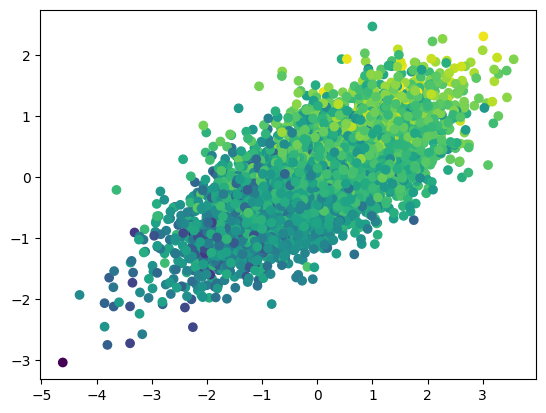

In [24]:
from sklearn.decomposition import PCA

with torch.no_grad():
    Xt = torch.from_numpy(X).to(device)
    ZA = penA(Xt).cpu().numpy()
    ZB = penB(Xt).cpu().numpy()

pca = PCA(1)
pca_za = pca.fit_transform(ZA)
print(pca.explained_variance_ratio_)
pca = PCA(1)
pca_zb = pca.fit_transform(ZB)
print(pca.explained_variance_ratio_)
pca = PCA(1)
pca_y = pca.fit_transform(Y)
print(pca.explained_variance_ratio_)

plt.scatter(pca_za, pca_zb, c=pca_y)

In [30]:
from sklearn.linear_model import HuberRegressor

model_a = HuberRegressor()
model_a.fit(ZA, pca_y)
model_b = HuberRegressor()
model_b.fit(ZB, pca_y)

outliers_a = model_a.outliers_
outliers_b = model_b.outliers_
print(f"{outliers_a.sum()} outliers in A")
print(f"{outliers_b.sum()} outliers in B")
outliers_both = outliers_a & outliers_b
print(f"{outliers_both.sum()} outliers in both")
trusted_a = ~outliers_a & outliers_b
trusted_b = ~outliers_b & outliers_a
print(f"{trusted_a.sum()} trsuted in A")
print(f"{trusted_b.sum()} trusted in B")


1715 outliers in A
1691 outliers in B
828 outliers in both
863 trsuted in A
887 trusted in B


c:\Users\raian\source\repos\AI\.env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\raian\source\repos\AI\.env\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [33]:
from sklearn.linear_model import LinearRegression
model_a = LinearRegression()
model_a.fit(ZA[trusted_a], Y[trusted_a])

model_b = LinearRegression()
model_b.fit(ZB[trusted_b], Y[trusted_b])

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
pred_a = model_a.predict(ZA)
pred_b = model_b.predict(ZB)

diff_a = np.sum((pred_a-Y)**2, axis=1)
diff_b = np.sum((pred_b-Y)**2, axis=1)

labels = np.argmax(np.stack([diff_a, diff_b]), axis=0)
labels = np.where(labels == 1, "A", "B")
labels

array(['B', 'B', 'B', ..., 'B', 'B', 'A'], shape=(5000,), dtype='<U1')

In [56]:
ids = np.arange(1, len(labels) + 1)
out_df = pd.DataFrame({"ID": ids, "source": labels})
out_df.to_csv(OUT_PRED_CSV, index=False)
print(f"Saved predictions to: {OUT_PRED_CSV}  (IDs 0..{len(labels)-1})")

Saved predictions to: ./submission.csv  (IDs 0..4999)
